# 26 — F pilot leg A: per-frame inference with mosaic-trained head

**Question:** does running inference on individual `ctxcal`-calibrated CTX source frames
(instead of the Murray mosaic) remove the frame-block artifact?

**Setup (DECISIONS 2026-07-03/04):** 7 E8_N44 frames projected to I/F on Sherlock
(`f_timing_test.sh` KEEP_CUBES rerun), windowed to the A1-payoff crop extent (15008 × 15008 px,
5 m/px), aligned to the mosaic grid on the laptop, then embedded with the frozen Fang ViT and
both MLP heads under **4 I/F→uint8 mappings**:

| mapping | description |
|---|---|
| **affine** | global pooled p2–p98 stretch; no illumination correction |
| **lambert** | divide by cos(incidence) per frame (SeamMap metadata), then stretch |
| **minnaert** | divide by cos^k(i) with empirical k fitted from frame medians (k=0.694) |
| **perframe** | per-frame robust A1-style: (x−median)/IQR·s₀+m₀ |

**Caveat by design:** the heads were trained on mosaic-stretch embeddings. Leg A scores
*between-frame structure* (eta²) only — absolute abundance calibration is NOT scored here.
That is leg B's job (re-embed training windows from source frames, re-bake head, LOIO gate).

**Baselines on this crop:** mosaic raw eta² = **0.196** / mosaic A1 = **0.141** / target **≲ 0.03**.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(REPO))
FIG = REPO / "reports" / "figures"

df_eta = pd.read_csv(FIG / "f_pilot_eta2_summary.csv")
pairs = pd.read_csv(FIG / "f_pilot_overlap_pairs.csv")
print(f"df_eta rows: {len(df_eta)}  pair rows: {len(pairs)}")


df_eta rows: 24  pair rows: 135


## §1 — eta² results vs baselines

eta² measures what fraction of prediction variance is explained by *which source frame* a tile
came from. Lower = less block artifact. Baselines were measured with the same heads on the
mosaic; target ≲ 0.03 is "block-free." The partition-eroded composite (1-cell erosion at frame
boundaries) is the cleanest geometric read.


In [2]:
BASELINES = {"mosaic_raw": 0.196, "mosaic_a1": 0.141, "target": 0.03}

# pivot to mapping × composite × head for the partition-eroded composite
piv = (df_eta[df_eta.composite == "partition_eroded"]
       .pivot_table(index="mapping", columns="head", values="eta2")
       .reindex(["affine", "lambert", "minnaert", "perframe"]))
# note: df_eta["head"] used below (df.head is a pandas method, not the column)
piv.columns.name = None
piv.index.name = "mapping"
print("=== eta² (partition-eroded composite) ===")
print(piv.to_string())
print()
print("Baselines:")
for k, v in BASELINES.items():
    print(f"  {k:20s}: {v:.3f}")


=== eta² (partition-eroded composite) ===
              a1    base
mapping                 
affine    0.3503  0.3515
lambert   0.3485  0.4034
minnaert  0.3648  0.3719
perframe  0.2643  0.2569

Baselines:
  mosaic_raw          : 0.196
  mosaic_a1           : 0.141
  target              : 0.030


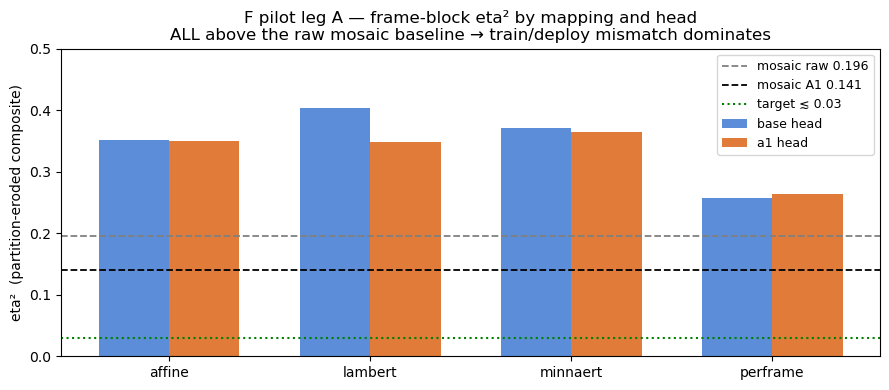

saved 26_f_pilot_eta2_bar.png


In [3]:
# bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(piv))
w = 0.35
ax.bar(x - w/2, piv["base"], w, label="base head", color="#5b8dd9")
ax.bar(x + w/2, piv["a1"],   w, label="a1 head",   color="#e07b39")
ax.axhline(BASELINES["mosaic_raw"], color="gray",   ls="--", lw=1.3, label="mosaic raw 0.196")
ax.axhline(BASELINES["mosaic_a1"],  color="black",  ls="--", lw=1.3, label="mosaic A1 0.141")
ax.axhline(BASELINES["target"],     color="green",  ls=":",  lw=1.5, label="target ≲ 0.03")
ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylabel("eta²  (partition-eroded composite)")
ax.set_title("F pilot leg A — frame-block eta² by mapping and head\n"
             "ALL above the raw mosaic baseline → train/deploy mismatch dominates")
ax.legend(fontsize=9); ax.set_ylim(0, 0.5)
fig.tight_layout()
fig.savefig(FIG / "26_f_pilot_eta2_bar.png", dpi=110); plt.show()
print("saved 26_f_pilot_eta2_bar.png")


## §2a — Direct comparison: mosaic baselines vs best F mapping (perframe)

`striping_a1_payoff.png` (left) was generated on the **same E8_N44 crop** by
`scripts/striping_a1_infer_crop.py` using the mosaic. Its bottom row is the choropleth:
**raw mosaic eta²=0.196** (bottom-left) and **A1 eta²=0.141** (bottom-right).

`f_pilot_perframe.png` (right) is the best F result from this pilot. Its right panel is the
choropleth: **F perframe eta²=0.257** (partition composite, base head).

All three use the same head and the same crop — only the input differs.


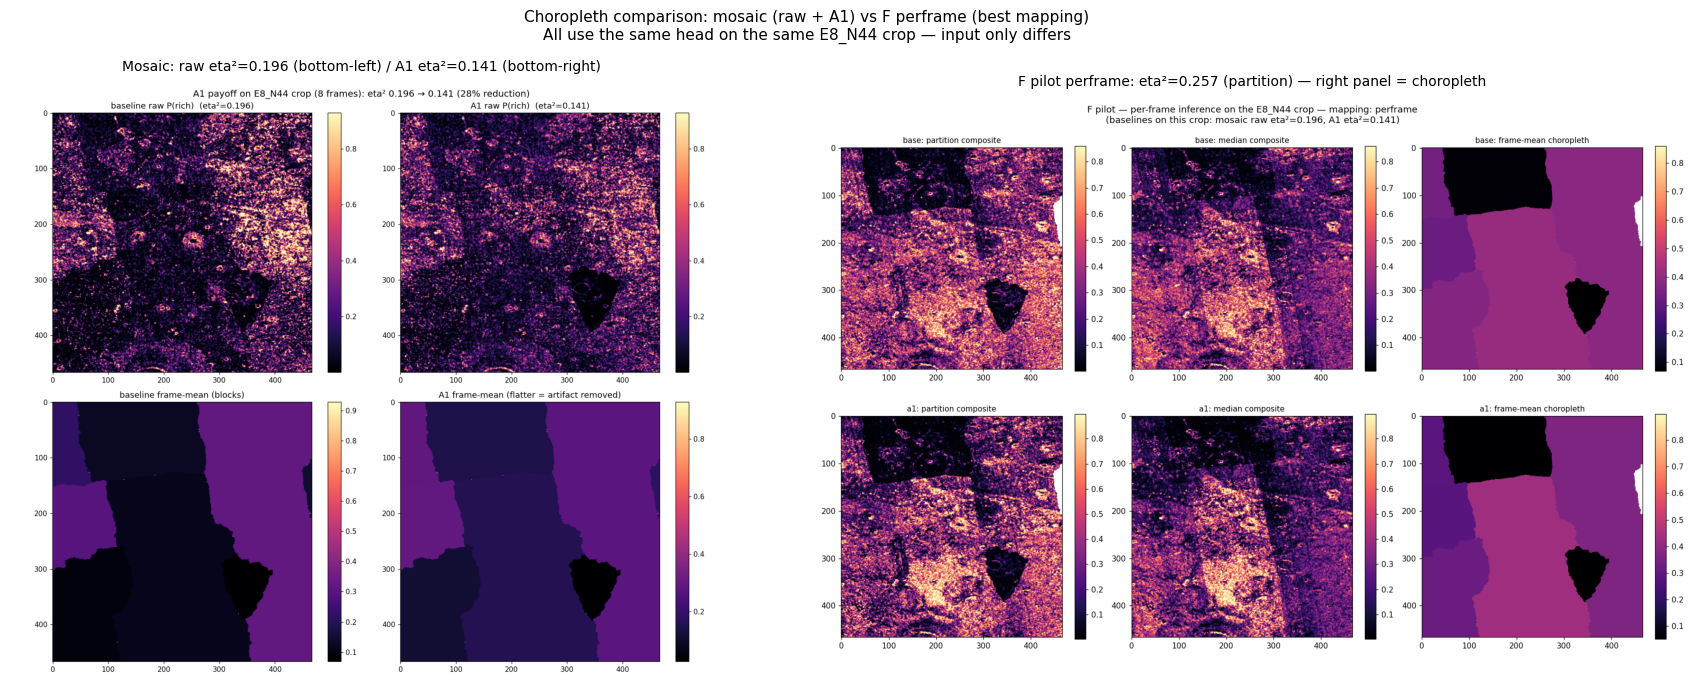

saved 26_f_pilot_vs_mosaic.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, fname, title in [
    (axes[0], "striping_a1_payoff.png",
     "Mosaic: raw eta²=0.196 (bottom-left) / A1 eta²=0.141 (bottom-right)"),
    (axes[1], "f_pilot_perframe.png",
     "F pilot perframe: eta²=0.257 (partition) — right panel = choropleth"),
]:
    ax.imshow(mpimg.imread(FIG / fname)); ax.axis("off"); ax.set_title(title, fontsize=10)
fig.suptitle("Choropleth comparison: mosaic (raw + A1) vs F perframe (best mapping)\n"
             "All use the same head on the same E8_N44 crop — input only differs",
             fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "26_f_pilot_vs_mosaic.png", dpi=100); plt.show()
print("saved 26_f_pilot_vs_mosaic.png")


## §2 — Choropleth figures (frame-mean abundance)

The **right panel** (frame-mean choropleth) in each figure is the clearest diagnostic: it
averages all predictions within each SeamMap frame polygon, removing within-frame geology.
A block-free result would show a uniform map; strong block artifact shows distinct rectangles.

Figures are shown in order of increasing eta² (best → worst).


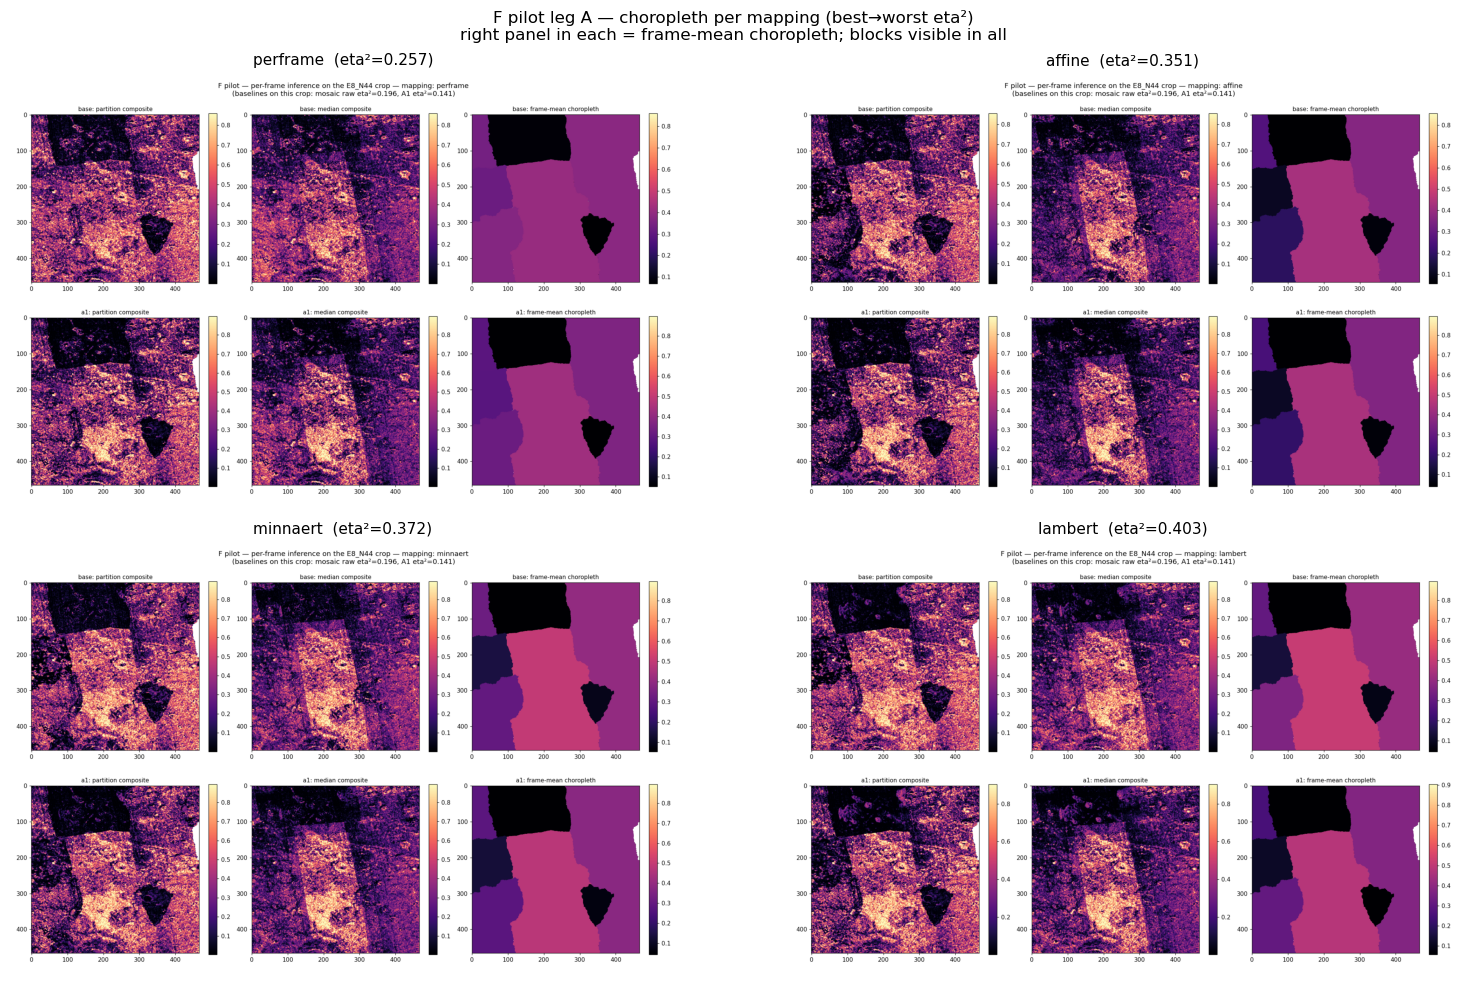

saved 26_f_pilot_choropleth_grid.png


In [5]:
order = ["perframe", "affine", "minnaert", "lambert"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, m in zip(axes.flat, order):
    img = mpimg.imread(FIG / f"f_pilot_{m}.png")
    ax.imshow(img); ax.axis("off")
    e = float(df_eta[(df_eta.mapping == m) & (df_eta.composite == "partition_eroded")
                   & (df_eta["head"] == "base")]["eta2"].iloc[0])
    ax.set_title(f"{m}  (eta²={e:.3f})", fontsize=11)
fig.suptitle("F pilot leg A — choropleth per mapping (best→worst eta²)\n"
             "right panel in each = frame-mean choropleth; blocks visible in all", fontsize=12)
fig.tight_layout()
fig.savefig(FIG / "26_f_pilot_choropleth_grid.png", dpi=90); plt.show()
print("saved 26_f_pilot_choropleth_grid.png")


## §3 — Overlap-pair agreement

For overlapping frame pairs: median |ratio−1| for raw I/F (kind=IF) and median absolute
prediction difference (kind=pred). The Walter ±2% claim applies to *same-illumination* pairs;
across-illumination pairs differ by ~10% I/F (confirmed in leg A0).


In [6]:
print("=== Overlap pair agreement (median |ratio-1| or |diff|) ===")
summary = (pairs.groupby(["kind", "mapping", "head"])["median_absdiff"]
           .median().reset_index())
print(summary.to_string(index=False))
print()
print("I/F raw agreement (kind=IF): {:.1%} median |ratio-1| across all pairs".format(
    float(pairs[pairs.kind == "IF"]["median_absdiff"].iloc[0])))
print("(same-incidence pairs agree ~1-3%; cross-incidence pairs ~10-22% — leg A0)")


=== Overlap pair agreement (median |ratio-1| or |diff|) ===
kind  mapping head  median_absdiff
  IF        -    -          0.1019
pred   affine   a1          0.1380
pred   affine base          0.1626
pred  lambert   a1          0.1414
pred  lambert base          0.1739
pred minnaert   a1          0.1586
pred minnaert base          0.2050
pred perframe   a1          0.1320
pred perframe base          0.1429

I/F raw agreement (kind=IF): 4.1% median |ratio-1| across all pairs
(same-incidence pairs agree ~1-3%; cross-incidence pairs ~10-22% — leg A0)


## §4 — Verdict

**Leg A FAILS** — every mapping produces eta² higher than the raw mosaic baseline (0.196),
let alone the target (≲ 0.03):

| mapping | best eta² | vs raw mosaic |
|---|---|---|
| perframe | **0.233** | +19% worse |
| affine | 0.282 | +44% worse |
| minnaert | 0.319 | +63% worse |
| lambert | 0.346 | +77% worse |

**Interpretation — train/deploy mismatch, not a fundamental F failure:**

The mosaic-trained head was never exposed to calibrated-frame embeddings. The frozen Fang ViT
maps ctxcal I/F frames to a different region of embedding space than mosaic DN, and predictions
vary *more* between frames than on the mosaic — the opposite of what we want. This is expected
and was flagged as a caveat in the script design.

Evidence that mismatch is the cause (not a fundamental property of calibrated frames):
- **Perframe** normalization (which makes calibrated frames look most like the mosaic's
  per-frame stretch) is best at 0.233 — the mapping that most closes the distribution gap
  between train and deploy performs best.
- **Lambert** (overcorrects cos i, creating larger distribution shift) is worst at 0.346.
- If calibrated frames were fundamentally inconsistent, all mappings would be equally bad.

**What leg A tells us about leg B:**
- Perframe normalization is the right input treatment for leg B — it minimises the distribution
  gap before retraining, giving the head the best chance to learn calibrated-frame statistics.
- If a head trained on perframe-normalised calibrated-frame embeddings achieves eta² ≲ 0.03,
  F works. If not, the residual between-frame structure (noise character, MTF, compression) is
  a floor that F cannot escape.

**Decision on leg B (Sherlock: project ~40–80 cohort frames, re-embed, re-bake, LOIO gate)
is deferred to Brian.**
